# Practice 8
## Objectives:
1. Understand the use of Gradient Boosting.
2. Understand the use of crossvalidation
3. Criterion for exploring the space of parameters
4. Be able to predict the mortality  (Total age-adjusted mortality rate per 100) and make a ranking of the data.
taken from: http://lib.stat.cmu.edu/datasets/pollution

## Explanation of the database
### Note the heterogeniety of the input variables.
This is the pollution data so loved by writers of papers on ridge regression.
Source: McDonald, G.C. and Schwing, R.C. (1973) 'Instabilities of regression
estimates relating air pollution to mortality', Technometrics, vol.15, 463-
482.

Variables in order:
* PREC   Average annual precipitation in inches
* JANT   Average January temperature in degrees F
* JULT   Same for July
* OVR65  % of 1960 SMSA population aged 65 or older
* POPN   Average household size
* EDUC   Median school years completed by those over 22
* HOUS   % of housing units which are sound & with all facilities
* DENS   Population per sq. mile in urbanized areas
* NONW   % non-white population in urbanized areas
* WWDRK  % employed in white collar occupations
* POOR   % of families with income < $3000
* HC     Relative hydrocarbon pollution potential
* NOX    Same for nitric oxides
* SO@    Same for sulphur dioxide
* HUMID  Annual average \% relative humidity at 1pm
* MORT   Total age-adjusted mortality rate per 100

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error

In [2]:
File = "pollution.txt"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename,  index_col=None,delimiter=r"\s+")
print(f'_'*50)
print(f'Shape of the database:{Data.shape}')
Data.head()


Filename with path: 
 c:\mlearn-lab\EightPractice\Data\pollution.txt
__________________________________________________
Shape of the database:(60, 16)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,y
0,36,27,71,8.1,3.34,11.4,81.5,3243,8.8,42.6,11.7,21,15,59,59,921.87
1,35,23,72,11.1,3.14,11.0,78.8,4281,3.5,50.7,14.4,8,10,39,57,997.88
2,44,29,74,10.4,3.21,9.8,81.6,4260,0.8,39.4,12.4,6,6,33,54,962.35
3,47,45,79,6.5,3.41,11.1,77.5,3125,27.1,50.2,20.6,18,8,24,56,982.29
4,43,35,77,7.6,3.44,9.6,84.6,6441,24.4,43.7,14.3,43,38,206,55,1071.29


In [3]:
ColumnName = 'PREC,JANT,JULT,OVR65,POPN,EDUC,HOUS,DENS,NONW,WWDRK,POOR,HC,NOX,SO,HUMID,MORT'
ColumnName = ColumnName.split(',')
print( f'Size of the input vector:{len(ColumnName)-1}')

Size of the input vector:15


In [4]:
Data.columns = ColumnName
Data.head().T

,0,1,2,3,4
PREC,36.00,35.00,44.00,47.00,43.00
JANT,27.00,23.00,29.00,45.00,35.00
JULT,71.00,72.00,74.00,79.00,77.00
OVR65,8.10,11.10,10.40,6.50,7.60
POPN,3.34,3.14,3.21,3.41,3.44
EDUC,11.40,11.00,9.80,11.10,9.60
HOUS,81.50,78.80,81.60,77.50,84.60
DENS,3243.00,4281.00,4260.00,3125.00,6441.00
NONW,8.80,3.50,0.80,27.10,24.40
WWDRK,42.60,50.70,39.40,50.20,43.70


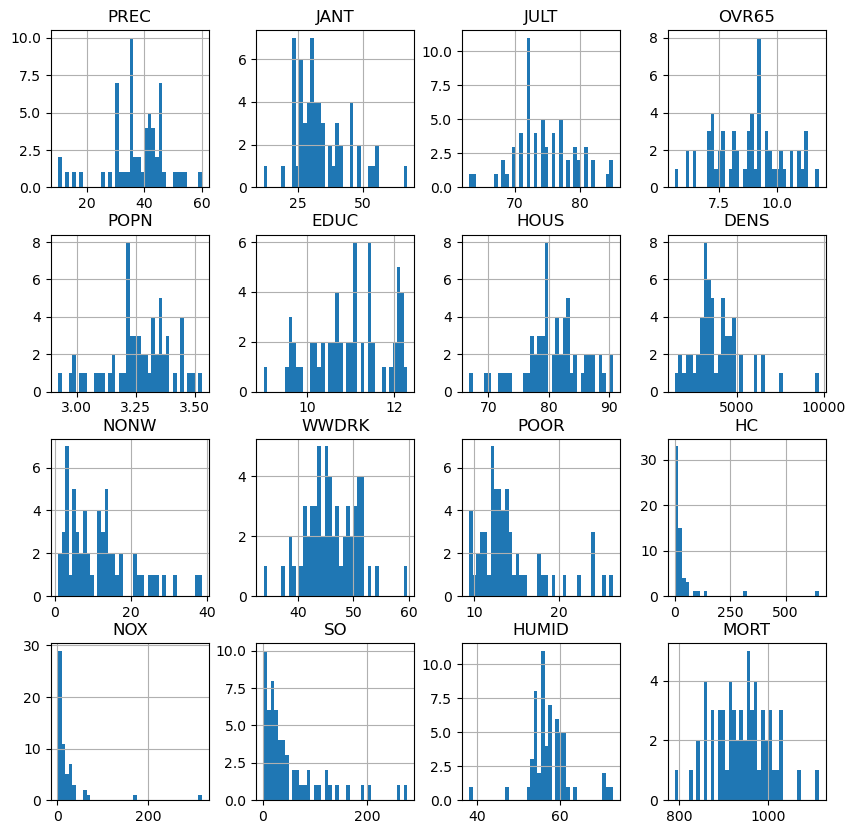

In [5]:
ax =Data.hist(figsize= (10,10),bins = 40)

## Homework: <font color='red'> Give a summary by words of the statistical distributions.</font>
## Homework: <font color='red'> Justify brifly why a Machine Learning algorithm based on linear projection might not work well with this database. (note that this includes all methods based on dot products).</font>
## Homework: <font color='red'> In case this you used linear regression, which preprocessing would you do on the data?.</font>

## Homework: <font color='red'> Print a simple decision tree in order to understand the dependencies of the features on the target database.</font>

## Helper function for creating a particion of the data base

In [6]:
Data.columns

Index(['PREC', 'JANT', 'JULT', 'OVR65', 'POPN', 'EDUC', 'HOUS', 'DENS', 'NONW',
       'WWDRK', 'POOR', 'HC', 'NOX', 'SO', 'HUMID', 'MORT'],
      dtype='object')

In [7]:
y = Data['MORT']
X = Data[ColumnName[:-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=0)

In [8]:
print('Sizes of the databases')
print(f' Size train: {X_train.shape[0]} \n Size validation: {X_valid.shape[0]} \n Size test: {X_test.shape[0]}')

Sizes of the databases
 Size train: 33 
 Size validation: 12 
 Size test: 15


## Gradient boosting

### Traing gradient boosting with default parameters
### See the effect of overfitting.

In [9]:
regGradBoost = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,max_depth=3, subsample = 0.95, loss='squared_error', random_state=0)
regGradBoost.fit(X_train, y_train)
MSE_Test = mean_squared_error(y_test, regGradBoost.predict(X_test))
MSE_Valid = mean_squared_error(y_valid, regGradBoost.predict(X_valid))
MSE_Train = mean_squared_error(y_train, regGradBoost.predict(X_train))
print(' MSE in each databases')
print(f' MSE_Train: {MSE_Train} \n MSE_Valid: {MSE_Valid} \n MSE_Test : {MSE_Test}')


 MSE in each databases
 MSE_Train: 1.6965869663207569e-15 
 MSE_Valid: 2953.195413121049 
 MSE_Test : 1748.6883995316057


In [10]:
print(' MSE in each databases')
print(f' MSE_Train: {MSE_Train:2.2f} \n MSE_Valid: {MSE_Valid:2.2f} \n MSE_Test : {MSE_Test:2.2f}')

 MSE in each databases
 MSE_Train: 0.00 
 MSE_Valid: 2953.20 
 MSE_Test : 1748.69


<Axes: >

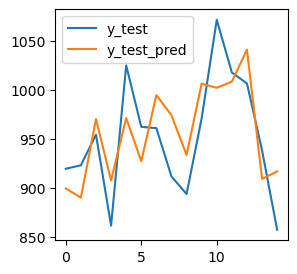

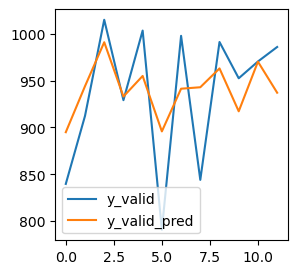

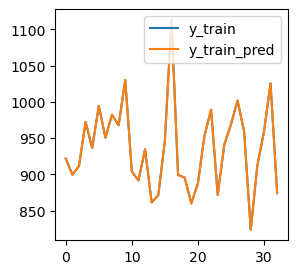

In [11]:
data_test = {'y_test': y_test.values, 'y_test_pred' :regGradBoost.predict(X_test)}
DataFrameResults_test = pd.DataFrame(data_test)
DataFrameResults_test.plot(figsize = (3,3))

data_valid = {'y_valid': y_valid.values, 'y_valid_pred' :regGradBoost.predict(X_valid)}
DataFrameResults_valid = pd.DataFrame(data_valid)
DataFrameResults_valid.plot(figsize = (3,3))
data_test = {'y_train': y_train.values, 'y_train_pred' :regGradBoost.predict(X_train)}
DataFrameResults_train = pd.DataFrame(data_test)
DataFrameResults_train.plot(figsize = (3,3))

## Homework: <font color='red'> Explain the origin of the overfitting observed above, and comment why giving the performance on the train database is erroneous.</font>

## Evolution of error with the number of boosting trees

In [12]:
RMSE_Test,RMSE_Valid,RMSE_Train = list(),list(),list()
for n_estimators in range(10,1000,50):
    regGradBoost = GradientBoostingRegressor(n_estimators=n_estimators, learning_rate=0.1,max_depth=3, random_state=0, loss='squared_error', subsample = 0.95)
    regGradBoost.fit(X_train, y_train)
    RMSE_Test.append(np.sqrt(mean_squared_error(y_test, regGradBoost.predict(X_test))))
    RMSE_Valid.append(np.sqrt(mean_squared_error(y_valid, regGradBoost.predict(X_valid))))
    RMSE_Train.append(np.sqrt(mean_squared_error(y_train, regGradBoost.predict(X_train))))


In [13]:
index_sliced = list(range(10, 1000, 50))[:len(RMSE_Train)]

df_RMSE_Train = pd.DataFrame(RMSE_Train, index=index_sliced, columns=['RMSE_Train'])
df_RMSE_Valid = pd.DataFrame(RMSE_Valid, index=index_sliced, columns=['RMSE_Valid'])
df_RMSE_Test = pd.DataFrame(RMSE_Test, index=index_sliced, columns=['RMSE_Test'])

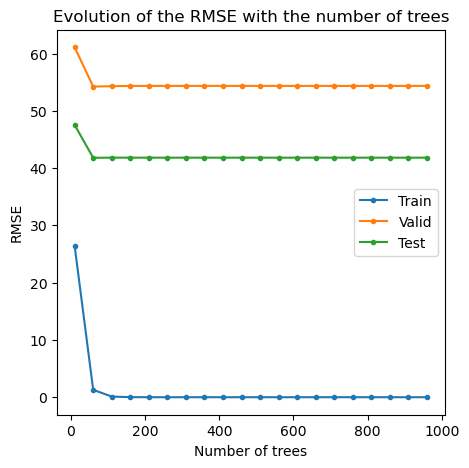

In [14]:

plt.figure(figsize=(5, 5))

# Plot each DataFrame using its index for the x-axis and the RMSE column for the y-axis
plt.plot(df_RMSE_Train.index, df_RMSE_Train['RMSE_Train'], '.-', label='Train')
plt.plot(df_RMSE_Valid.index, df_RMSE_Valid['RMSE_Valid'], '.-', label='Valid')
plt.plot(df_RMSE_Test.index, df_RMSE_Test['RMSE_Test'], '.-', label='Test')

# Set chart titles and axis labels
plt.title('Evolution of the RMSE with the number of trees')
plt.xlabel('Number of trees')
plt.ylabel('RMSE')

# Add a legend to differentiate the Train, Validation, and Test lines
plt.legend()

# Display the plot
plt.show()

In [15]:
RMSE_Test,RMSE_Valid,RMSE_Train = list(),list(),list()
for max_depth in range(1,15,1):
    regGradBoost = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1,max_depth=max_depth, random_state=0, loss='squared_error', subsample = 0.95)
    regGradBoost.fit(X_train, y_train)
    RMSE_Test.append(np.sqrt(mean_squared_error(y_test, regGradBoost.predict(X_test))))
    RMSE_Valid.append(np.sqrt(mean_squared_error(y_valid, regGradBoost.predict(X_valid))))
    RMSE_Train.append(np.sqrt(mean_squared_error(y_train, regGradBoost.predict(X_train))))

In [16]:

index_range = list(range(1, 15, 1))

# Create the DataFrames using the new index
df_RMSE_Train = pd.DataFrame(RMSE_Train, index=index_range, columns=['RMSE_Train'])
df_RMSE_Valid = pd.DataFrame(RMSE_Valid, index=index_range, columns=['RMSE_Valid'])
df_RMSE_Test = pd.DataFrame(RMSE_Test, index=index_range, columns=['RMSE_Test'])

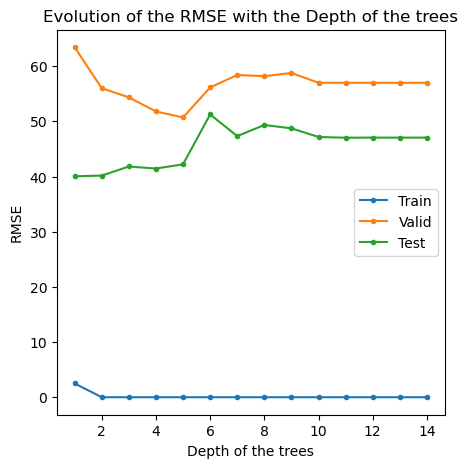

In [17]:


plt.figure(figsize=(5, 5))
plt.plot(df_RMSE_Train.index, df_RMSE_Train['RMSE_Train'], '.-', label='Train')
plt.plot(df_RMSE_Valid.index, df_RMSE_Valid['RMSE_Valid'], '.-', label='Valid')
plt.plot(df_RMSE_Test.index, df_RMSE_Test['RMSE_Test'], '.-', label='Test')
plt.title('Evolution of the RMSE with the Depth of the trees')
plt.xlabel('Depth of the trees')
plt.ylabel('RMSE')
plt.legend()
plt.show()

## Note the flattening of the curve due to overfitting!!!!!

# Next we will do cross validation in order to simulate unseen data better

## Explanation of Cross validation.
Taken from https://scikit-learn.org/stable/modules/cross_validation.html

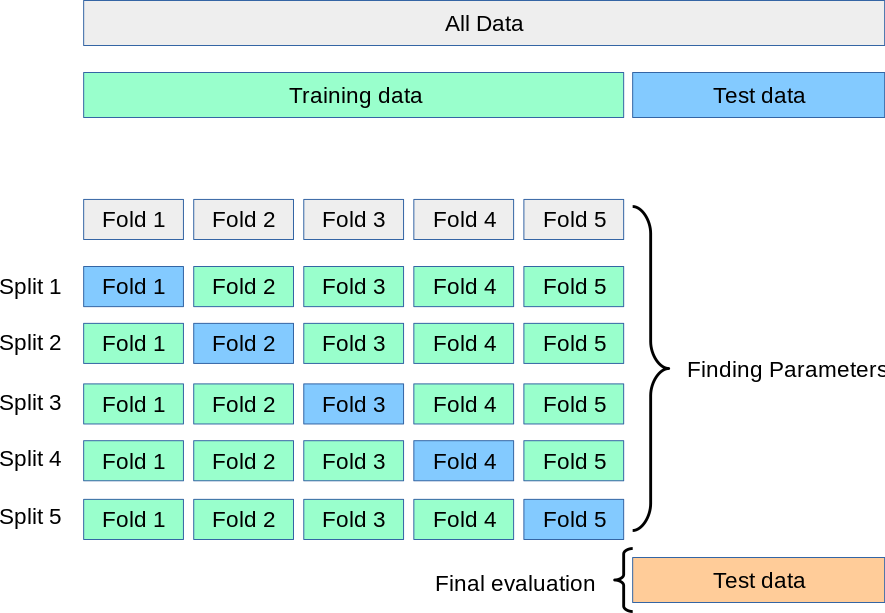

In [18]:
y = Data['MORT']
X = Data[ColumnName[:-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

## Let us use the implementation of cross validation in sklearn.
### Note the structure of the score
### Note the uncorrelation between test and train and the difference

In [19]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB

In [20]:
InputFeatures = [fea for fea in Data.columns if  fea != 'MORT']
print(f' Input variables: \n {InputFeatures}')

 Input variables: 
 ['PREC', 'JANT', 'JULT', 'OVR65', 'POPN', 'EDUC', 'HOUS', 'DENS', 'NONW', 'WWDRK', 'POOR', 'HC', 'NOX', 'SO', 'HUMID']


In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid to test
param_grid = {
    'n_estimators': [10, 50, 100, 1000, 1500],
    'learning_rate': [0.001, 0.01, 0.1],
    'max_depth': [1, 2, 5, 10]
}

# 2. Initialize the base model
gbr = GradientBoostingRegressor(random_state=42)

# 3. Create GridSearchCV with 10-fold cross-validation
# Using negative RMSE as the scoring metric
gbr_cv = GridSearchCV(
    estimator=gbr, 
    param_grid=param_grid, 
    cv=10, 
    scoring='neg_root_mean_squared_error',  # Use negative MSE for scoring
    n_jobs=-1  # Uses all available CPU cores to speed up computation
)

# 4. Prepare fresh training data (Keep your existing database partition logic)
TrainDB_cv, TestDB_cv = PartitionOfDatabase(Data, Fraction=0.75)
TrainDB_cv = TrainDB_cv.astype('float')
TestDB_cv = TestDB_cv.astype('float')
y_train = TrainDB_cv['MORT']
X_train = TrainDB_cv[InputFeatures]
y_test = TestDB_cv['MORT']
X_test = TestDB_cv[InputFeatures]

# 5. Fit the grid search with cross-validation
gbr_cv.fit(X_train, y_train)

# 6. Extract and display the results
best_params = gbr_cv.best_params_
# Convert negative RMSE back to positive RMSE
best_cv_rmse = -gbr_cv.best_score_ 

print("Optimal parameters found by cross-validation:")
print(f"  - n_estimators: {best_params['n_estimators']}")
print(f"  - learning_rate: {best_params['learning_rate']}")
print(f"  - max_depth: {best_params['max_depth']}")
print(f"\nBest Cross-Validation RMSE: {best_cv_rmse:.4f}")

# Optional: Evaluate the best model on your test set
best_model = gbr_cv.best_estimator_
test_predictions = best_model.predict(X_test)

Optimal parameters found by cross-validation:
  - n_estimators: 50
  - learning_rate: 0.1
  - max_depth: 2

Best Cross-Validation RMSE: 34.9899


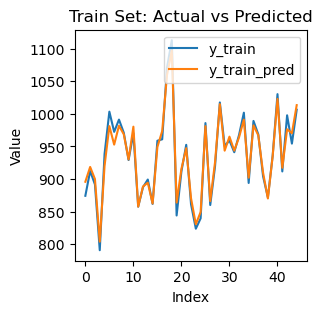

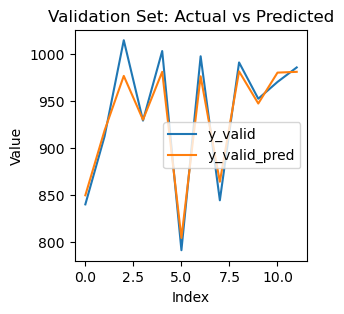

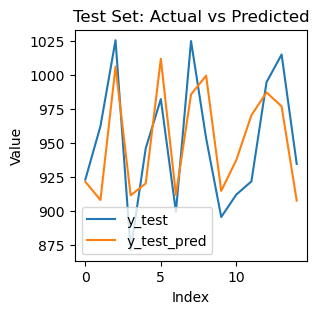

In [22]:

# 1. Extract the best model from your grid search
best_reg_gbr = gbr_cv.best_estimator_

# 2. Train Set Predictions & Plot
data_train = {
    'y_train': y_train.values, 
    'y_train_pred': best_reg_gbr.predict(X_train)
}
DataFrameResults_train = pd.DataFrame(data_train)
DataFrameResults_train.plot(figsize=(3, 3))
plt.title('Train Set: Actual vs Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

# 3. Validation Set Predictions & Plot
# (Only runs if you have an explicit X_valid defined in your workspace)
if 'X_valid' in locals() or 'X_valid' in globals():
    data_valid = {
        'y_valid': y_valid.values, 
        'y_valid_pred': best_reg_gbr.predict(X_valid)
    }
    DataFrameResults_valid = pd.DataFrame(data_valid)
    DataFrameResults_valid.plot(figsize=(3, 3))
    plt.title('Validation Set: Actual vs Predicted')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.show()
else:
    print("Skipping Validation Plot: 'X_valid' is not explicitly defined in the workspace.")

# 4. Test Set Predictions & Plot
data_test = {
    'y_test': y_test.values, 
    'y_test_pred': best_reg_gbr.predict(X_test)
}
DataFrameResults_test = pd.DataFrame(data_test)
DataFrameResults_test.plot(figsize=(3, 3))
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

## Let us see the relative importance of each variable.

<Axes: >

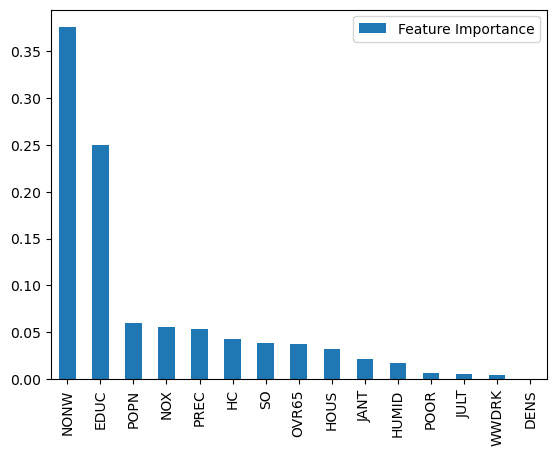

In [23]:
regGradBoost = GradientBoostingRegressor(n_estimators=10, learning_rate=0.1,max_depth=3, random_state=0, loss='squared_error', subsample = 0.95)
regGradBoost.fit(X_train, y_train)
FeatureImportance = pd.DataFrame(regGradBoost.feature_importances_,columns = ['Feature Importance'])
FeatureImportance.index = ColumnName[:-1]
FeatureImportance.sort_values(by = ['Feature Importance'],inplace = True, ascending=False)
FeatureImportance.plot.bar()

## Homework: <font color='red'> Give an interpretation of the plausability of the variable ranking (try a sociological explanation).</font>
## Homework: <font color='red'> Comment briefly on the difference of ranking with the decision trees.</font>
## Homework: <font color='red'> Given the ranking think of feature engineering that might improve the performance.</font>

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.
